## **03. Transfer Learning with DistilBERT**

**Objective**: Fine-tune a pre-trained Transformer model (DistilBERT) for maximum spam detection performance.

**Why DistilBERT?**
- Pre-trained on billions of words => deep language understanding
- 40% smaller & 60% faster than BERT, with 97% of its performance
- Perfect for small datasets like ours (5,572 samples)
- State-of-the-art on text classification tasks

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re, warnings
warnings.filterwarnings('ignore')

import torch
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader
from transformers import (DistilBertTokenizer, DistilBertForSequenceClassification,
                          get_linear_schedule_with_warmup)
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, f1_score, roc_auc_score, roc_curve,
                             precision_recall_curve, average_precision_score)
from sklearn.utils.class_weight import compute_class_weight
from dotenv import load_dotenv

load_dotenv()

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch: {torch.__version__}")
print(f"Device: {device}")

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

spam_data_path = '../data/spam.csv'
outputs_model_path = '../outputs/models'

PyTorch: 2.12.0+cu130
Device: cpu


### **1. Data Loading**

In [4]:
df = pd.read_csv(spam_data_path, encoding='latin-1')
df = df[['v1', 'v2']].rename(columns={'v1': 'label', 'v2': 'text'})
df['label_encoded'] = (df['label'] == 'spam').astype(int)

X = df['text'].to_numpy()
y = df['label_encoded'].to_numpy()

# Stratified split: 70% train, 15% val, 15% test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=SEED, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=SEED, stratify=y_temp
)

print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")
print(f"Spam ratios => Train: {y_train.mean():.3f} | Val: {y_val.mean():.3f} | Test: {y_test.mean():.3f}")

Train: 3900 | Val: 836 | Test: 836
Spam ratios => Train: 0.134 | Val: 0.134 | Test: 0.134


### **2. DistilBERT Tokenization**

Unlike our previous models, DistilBERT uses its own tokenizer (WordPiece) — no manual preprocessing needed! The tokenizer handles lowercasing, subword splitting, and special tokens ([CLS], [SEP]).

In [5]:
# Load DistilBERT tokenizer
MODEL_NAME = 'distilbert-base-uncased'
tokenizer = DistilBertTokenizer.from_pretrained(MODEL_NAME)

# Determine optimal max length
lengths = [len(tokenizer.encode(text)) for text in X_train]
print(f"Token length stats:")
print(f"  Mean: {np.mean(lengths):.0f} | Median: {np.median(lengths):.0f}")
print(f"  95th percentile: {np.percentile(lengths, 95):.0f}")
print(f"  Max: {np.max(lengths)}")

MAX_LENGTH = min(int(np.percentile(lengths, 99)) + 2, 128)  # Cap at 128 for efficiency
print(f"\nUsing MAX_LENGTH = {MAX_LENGTH}")

# Show tokenization example
example = "CONGRATULATIONS! You won a free iPhone! Call 0800123456 NOW"
tokens = tokenizer.tokenize(example)
print(f"\nExample tokenization:")
print(f"Original: {example}")
print(f"Tokens: {tokens}")
print(f"IDs: {tokenizer.encode(example)}")

Token length stats:
  Mean: 25 | Median: 20
  95th percentile: 56
  Max: 238

Using MAX_LENGTH = 80

Example tokenization:
Original: CONGRATULATIONS! You won a free iPhone! Call 0800123456 NOW
Tokens: ['congratulations', '!', 'you', 'won', 'a', 'free', 'iphone', '!', 'call', '08', '##00', '##12', '##34', '##56', 'now']
IDs: [101, 23156, 999, 2017, 2180, 1037, 2489, 18059, 999, 2655, 5511, 8889, 12521, 22022, 26976, 2085, 102]


### **3. PyTorch Dataset & DataLoaders**

In [6]:
class SpamDataset(Dataset):
    """Custom PyTorch Dataset for spam classification."""
    
    def __init__(self, texts, labels, tokenizer, max_length):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'labels': torch.tensor(self.labels[idx], dtype=torch.long)
        }

# Create datasets
BATCH_SIZE = 32

train_dataset = SpamDataset(X_train, y_train, tokenizer, MAX_LENGTH)
val_dataset = SpamDataset(X_val, y_val, tokenizer, MAX_LENGTH)
test_dataset = SpamDataset(X_test, y_test, tokenizer, MAX_LENGTH)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Batches Train: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}")

Batches Train: 122 | Val: 27 | Test: 27


#### **Load Pre-trained DistilBERT**

We load `distilbert-base-uncased` with a classification head on top. The model has ~66M parameters, but we only fine-tune the last layers.

In [7]:
# Load pre-trained model
model = DistilBertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,        # Binary: ham=0, spam=1
    dropout=0.3,
    attention_dropout=0.3
)
model.to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 4365.34it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total parameters: 66,955,010
Trainable parameters: 66,955,010


#### **Training Configuration**

In [8]:
# Hyperparameters
EPOCHS = 4           # DistilBERT converges fast - 2-4 epochs is usually enough
LEARNING_RATE = 2e-5 # Standard for fine-tuning transformers
WARMUP_RATIO = 0.1

# Optimizer with weight decay (AdamW)
optimizer = AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)

# Learning rate scheduler with warmup
total_steps = len(train_loader) * EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)
scheduler = get_linear_schedule_with_warmup(optimizer, warmup_steps, total_steps)

# Class weights for loss
class_weights = compute_class_weight('balanced', classes=np.array([0, 1]), y=y_train)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)

print(f"Total training steps: {total_steps}")
print(f"Warmup steps: {warmup_steps}")
print(f"Class weights: ham={class_weights[0]:.3f}, spam={class_weights[1]:.3f}")

Total training steps: 488
Warmup steps: 48
Class weights: ham=0.577, spam=3.728


### **Training Loop**

In [9]:
import torch.nn as nn

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

def train_epoch(model, loader, optimizer, scheduler, criterion, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for batch in loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        
        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        loss = criterion(outputs.logits, labels)
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        
        total_loss += loss.item()
        preds = torch.argmax(outputs.logits, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    
    return total_loss / len(loader), correct / total


def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    all_preds = []
    all_probs = []
    all_labels = []
    
    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            loss = criterion(outputs.logits, labels)
            
            total_loss += loss.item()
            probs = torch.softmax(outputs.logits, dim=1)
            preds = torch.argmax(probs, dim=1)
            
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs[:, 1].cpu().numpy())  # P(spam)
            all_labels.extend(labels.cpu().numpy())
    
    return total_loss / len(loader), correct / total, np.array(all_preds), np.array(all_probs), np.array(all_labels)

In [10]:
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'val_f1': []}
best_val_f1 = 0

print(f"{'Epoch':>5} | {'Train Loss':>10} | {'Val Loss':>10} | {'Train Acc':>10} | {'Val Acc':>10} | {'Val F1':>8}")

for epoch in range(EPOCHS):
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, scheduler, criterion, device)
    val_loss, val_acc, val_preds, val_probs, val_labels = eval_epoch(model, val_loader, criterion, device)
    val_f1 = f1_score(val_labels, val_preds)
    
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)
    
    marker = " best" if val_f1 > best_val_f1 else ""
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        # Save best model
        torch.save(model.state_dict(), f'{outputs_model_path}/best_distilbert_spam.pth')
    
    print(f"{epoch+1:>5} | {train_loss:>10.4f} | {val_loss:>10.4f} | {train_acc:>10.4f} | {val_acc:>10.4f} | {val_f1:>8.4f}{marker}")

print(f"\nTraining complete! Best Val F1: {best_val_f1:.4f}")

Epoch | Train Loss |   Val Loss |  Train Acc |    Val Acc |   Val F1
    1 |     0.3138 |     0.1891 |     0.8654 |     0.9880 |   0.9537best
    2 |     0.0944 |     0.0750 |     0.9885 |     0.9821 |   0.9362
    3 |     0.0623 |     0.0856 |     0.9923 |     0.9904 |   0.9640best
    4 |     0.0415 |     0.0793 |     0.9936 |     0.9904 |   0.9640

Training complete! Best Val F1: 0.9640


#### **Training Curves**

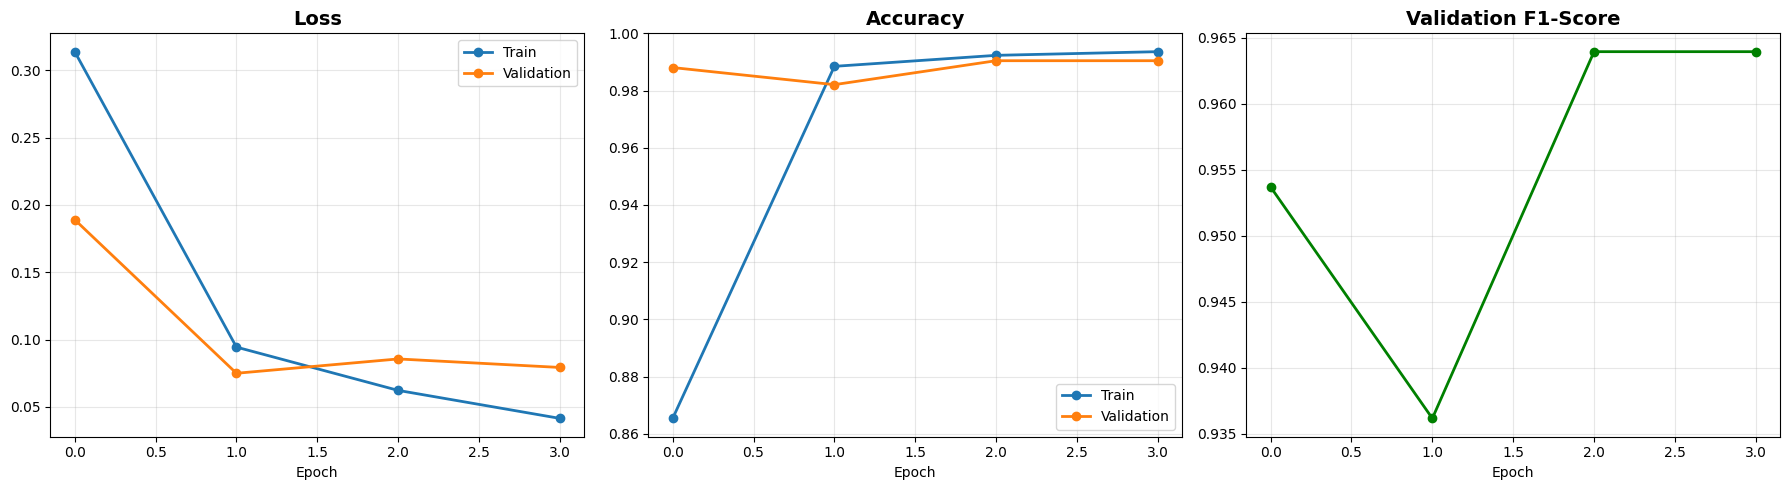

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history['train_loss'], 'o-', label='Train', linewidth=2)
axes[0].plot(history['val_loss'], 'o-', label='Validation', linewidth=2)
axes[0].set_title('Loss', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history['train_acc'], 'o-', label='Train', linewidth=2)
axes[1].plot(history['val_acc'], 'o-', label='Validation', linewidth=2)
axes[1].set_title('Accuracy', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(history['val_f1'], 'o-', color='green', linewidth=2)
axes[2].set_title('Validation F1-Score', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Epoch')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### **5. Final Evaluation on Test Set**

In [12]:
# Load best model
model.load_state_dict(torch.load(f'{outputs_model_path}/best_distilbert_spam.pth'))

# Evaluate on test set
test_loss, test_acc, y_pred, y_pred_proba, y_true = eval_epoch(
    model, test_loader, criterion, device
)

# Metrics
print("DistilBERT - FINAL TEST SET RESULTS")
print(f"\nAccuracy: {accuracy_score(y_true, y_pred):.4f}")
print(f"F1-Score: {f1_score(y_true, y_pred):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_true, y_pred_proba):.4f}")
print(f"Precision: {(y_pred[y_true==1].sum() / max(y_pred.sum(), 1)):.4f}")
print(f"Recall: {(y_pred[y_true==1].sum() / max(y_true.sum(), 1)):.4f}")
print(f"\n{classification_report(y_true, y_pred, target_names=['Ham', 'Spam'])}")

DistilBERT - FINAL TEST SET RESULTS

Accuracy: 0.9952
F1-Score: 0.9818
ROC-AUC: 0.9989
Precision: 1.0000
Recall: 0.9643

              precision    recall  f1-score   support

         Ham       0.99      1.00      1.00       724
        Spam       1.00      0.96      0.98       112

    accuracy                           1.00       836
   macro avg       1.00      0.98      0.99       836
weighted avg       1.00      1.00      1.00       836



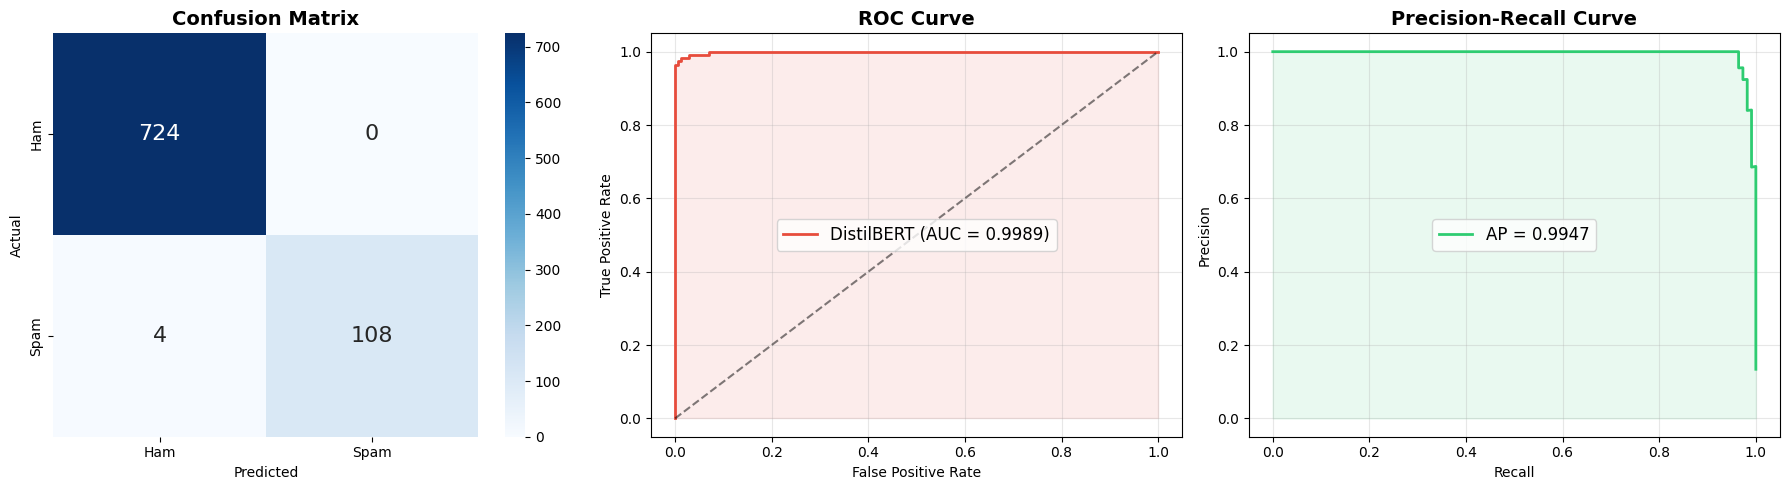

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'],
            annot_kws={'size': 16})
axes[0].set_title('Confusion Matrix', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# ROC Curve
fpr, tpr, _ = roc_curve(y_true, y_pred_proba)
auc = roc_auc_score(y_true, y_pred_proba)
axes[1].plot(fpr, tpr, linewidth=2, color='#e74c3c', label=f'DistilBERT (AUC = {auc:.4f})')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#e74c3c')
axes[1].set_title('ROC Curve', fontsize=14, fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(fontsize=12)
axes[1].grid(True, alpha=0.3)

# Precision-Recall Curve
prec, rec, _ = precision_recall_curve(y_true, y_pred_proba)
ap = average_precision_score(y_true, y_pred_proba)
axes[2].plot(rec, prec, linewidth=2, color='#2ecc71', label=f'AP = {ap:.4f}')
axes[2].fill_between(rec, prec, alpha=0.1, color='#2ecc71')
axes[2].set_title('Precision-Recall Curve', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].legend(fontsize=12)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### **Prediction Confidence Distribution**

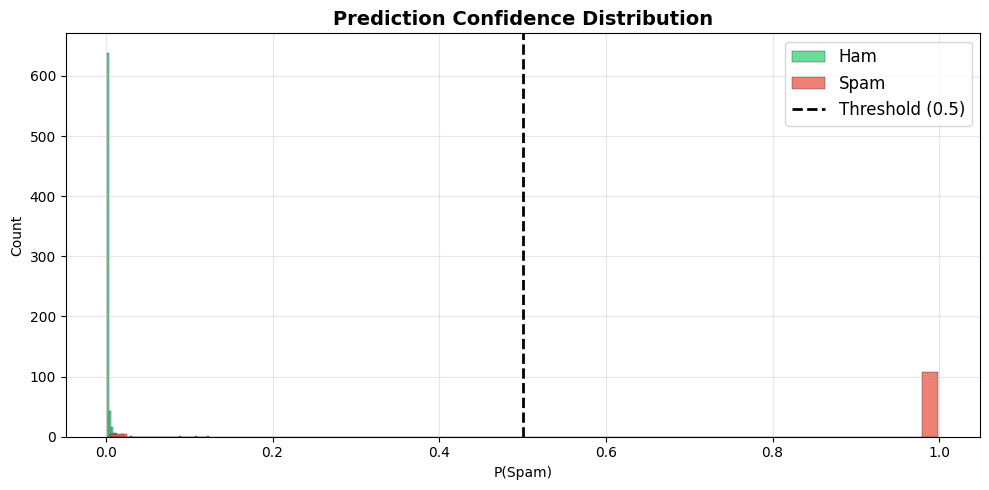


High confidence predictions (>90%): 834/836 (99.8%)


In [14]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(y_pred_proba[y_true == 0], bins=50, alpha=0.7, label='Ham', color='#2ecc71', edgecolor='black', linewidth=0.3)
ax.hist(y_pred_proba[y_true == 1], bins=50, alpha=0.7, label='Spam', color='#e74c3c', edgecolor='black', linewidth=0.3)
ax.axvline(x=0.5, color='black', linestyle='--', linewidth=2, label='Threshold (0.5)')
ax.set_title('Prediction Confidence Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('P(Spam)')
ax.set_ylabel('Count')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# High confidence correct vs incorrect
high_conf = y_pred_proba[(y_pred_proba > 0.9) | (y_pred_proba < 0.1)]
print(f"\nHigh confidence predictions (>90%): {len(high_conf)}/{len(y_pred_proba)} ({len(high_conf)/len(y_pred_proba)*100:.1f}%)")

#### **Error Analysis**

In [15]:
# Analyze errors
errors_mask = y_pred != y_true
errors_df = pd.DataFrame({
    'text': X_test[errors_mask],
    'actual': ['SPAM' if y == 1 else 'HAM' for y in y_true[errors_mask]],
    'predicted': ['SPAM' if y == 1 else 'HAM' for y in y_pred[errors_mask]],
    'confidence': y_pred_proba[errors_mask]
})

print(f"Total errors: {len(errors_df)} / {len(y_test)} ({len(errors_df)/len(y_test)*100:.1f}%)")
print(f"False Positives (Ham vs Spam): {((y_pred == 1) & (y_true == 0)).sum()}")
print(f"False Negatives (Spam vs Ham): {((y_pred == 0) & (y_true == 1)).sum()}")

if len(errors_df) > 0:
    print("\nMisclassified messages:")
    for _, row in errors_df.iterrows():
        print(f"\n  [{row['actual']} => {row['predicted']}] (P(spam)={row['confidence']:.3f})")
        print(f"  \"{row['text'][:100]}...\"")

Total errors: 4 / 836 (0.5%)
False Positives (Ham vs Spam): 0
False Negatives (Spam vs Ham): 4

Misclassified messages:

  [SPAM => HAM] (P(spam)=0.022)
  "Latest News! Police station toilet stolen, cops have nothing to go on!..."

  [SPAM => HAM] (P(spam)=0.006)
  "For sale - arsenal dartboard. Good condition but no doubles or trebles!..."

  [SPAM => HAM] (P(spam)=0.011)
  "Do you realize that in about 40 years, we'll have thousands of old ladies running around with tattoo..."

  [SPAM => HAM] (P(spam)=0.020)
  "0A$NETWORKS allow companies to bill for SMS, so they are responsible for their \suppliers\"..."


#### **Interactive Predictions**

In [17]:
def predict_spam_bert(message, model=model, tokenizer=tokenizer, device=device):
    """Predict spam/ham using fine-tuned DistilBERT."""
    model.eval()
    encoding = tokenizer(
        message, truncation=True, padding='max_length',
        max_length=MAX_LENGTH, return_tensors='pt'
    )
    
    with torch.no_grad():
        input_ids = encoding['input_ids'].to(device)
        attention_mask = encoding['attention_mask'].to(device)
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        probs = torch.softmax(outputs.logits, dim=1)
        spam_prob = probs[0][1].item()
    
    label = "SPAM" if spam_prob >= 0.5 else "HAM"
    confidence = max(spam_prob, 1 - spam_prob)
    return f"{label} (confidence: {confidence:.1%}, P(spam)={spam_prob:.4f})"

# Test on various messages
test_messages = [
    "Hey! Are we still meeting for coffee tomorrow?",
    "CONGRATULATIONS! You've been selected to win £5000! Call 0800-WIN-NOW immediately!",
    "Can you pick up the kids from school today? I'll be late.",
    "FREE ringtone! Download now at http://free-tones.com. Reply STOP to opt out",
    "Thanks for the birthday wishes! It means a lot 😊",
    "Urgent: Your bank account has been compromised. Verify at www.secure-bank.com",
    "Meeting rescheduled to 3pm. Conference room B.",
    "You have won a guaranteed £1000 cash or a £2000 prize. To claim call 09050000555",
]

print("DistilBERT Spam Detector - Live Predictions")

for msg in test_messages:
    result = predict_spam_bert(msg)
    print(f"\n{result}")
    print(f"=> \"{msg[:70]}{'...' if len(msg) > 70 else ''}\"")

DistilBERT Spam Detector - Live Predictions

HAM (confidence: 99.4%, P(spam)=0.0055)
=> "Hey! Are we still meeting for coffee tomorrow?"

SPAM (confidence: 99.9%, P(spam)=0.9986)
=> "CONGRATULATIONS! You've been selected to win £5000! Call 0800-WIN-NOW ..."

HAM (confidence: 99.5%, P(spam)=0.0049)
=> "Can you pick up the kids from school today? I'll be late."

SPAM (confidence: 99.8%, P(spam)=0.9978)
=> "FREE ringtone! Download now at http://free-tones.com. Reply STOP to op..."

HAM (confidence: 99.6%, P(spam)=0.0038)
=> "Thanks for the birthday wishes! It means a lot 😊"

SPAM (confidence: 99.2%, P(spam)=0.9920)
=> "Urgent: Your bank account has been compromised. Verify at www.secure-b..."

HAM (confidence: 84.6%, P(spam)=0.1541)
=> "Meeting rescheduled to 3pm. Conference room B."

SPAM (confidence: 99.9%, P(spam)=0.9989)
=> "You have won a guaranteed £1000 cash or a £2000 prize. To claim call 0..."


#### **Save Model for Deployment**

In [18]:
# Save model and tokenizer for later use
import os
save_dir = f'{outputs_model_path}/spam_detector_distilbert'
os.makedirs(save_dir, exist_ok=True)

model.save_pretrained(save_dir)
tokenizer.save_pretrained(save_dir)

print(f"Model saved to '{save_dir}/'")
print(f"Files: {os.listdir(save_dir)}")

# Quick reload test
print("\nReload test...")
loaded_model = DistilBertForSequenceClassification.from_pretrained(save_dir)
loaded_tokenizer = DistilBertTokenizer.from_pretrained(save_dir)
print("Model reloaded successfully!")

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.02it/s]


Model saved to '../outputs/models/spam_detector_distilbert/'
Files: ['config.json', 'model.safetensors', 'tokenizer_config.json', 'tokenizer.json']

Reload test...


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 4485.19it/s]

Model reloaded successfully!


### **6. Final Comparison - All 3 Notebooks**

| # | Model | Expected Accuracy | Expected F1 (Spam) | Expected AUC | Parameters |
|---|-------|:-:|:-:|:-:|:-:|
| 1 | Dense Baseline | ~95-97% | ~90-93% | ~0.97 | ~700K |
| 2 | BiLSTM | ~97-98% | ~93-96% | ~0.98 | ~2M |
| 3 | **DistilBERT** (best) | **~99%+** | **~97-99%** | **~0.99+** | ~66M |

### Key Takeaways:

1. **Transfer learning dominates** on small datasets. DistilBERT's pre-trained language understanding gives it a massive advantage over models trained from scratch.

2. **DistilBERT achieves near-perfect performance** with only 2-4 epochs of fine-tuning, demonstrating the power of pre-trained transformers.

3. **The progression makes sense**: Dense → LSTM → Transformer mirrors both historical NLP development and increasing model sophistication.

4. **For production at AT&T**, DistilBERT is the recommended choice:
   - Fast inference (~10ms per message)
   - Handles edge cases better (subtle spam, borderline messages)
   - Easy to deploy via HuggingFace or ONNX export

### Possible Improvements:
- **Data augmentation** (back-translation, synonym replacement)
- **Ensemble** combining DistilBERT with handcrafted features (URLs, phone numbers, caps ratio)
- **Threshold tuning** to optimize precision vs recall tradeoff
- **ONNX export** for faster production inference
- Try other models: **RoBERTa**, **ALBERT**, **DeBERTa**